# Reiforcement Learning ep.1: Q-Learning

<a target="_blank" href="https://colab.research.google.com/github/nickplas/Intro_to_ML_24-25/blob/main/notebooks/Lab-16.RL_QLearning.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

## Self-driving cab

Let's design a simulation of a self-driving cab. The major goal is to demonstrate, in a simplified environment, how you can use RL techniques to develop an efficient and safe approach for tackling this problem.

The Smartcab's job is to pick up the passenger at one location and drop them off in another. Here are a few things that we'd love our Smartcab to take care of:

* Drop off the passenger to the right location.
* Save passenger's time by taking minimum time possible to drop off
* Take care of passenger's safety and traffic rules


There are different aspects that need to be considered here while modeling an RL solution to this problem: rewards, states, and actions.

#### Rewards

Since the agent (the imaginary driver) is reward-motivated and is going to learn how to control the cab by trial experiences in the environment, we need to decide the rewards and/or penalties and their magnitude accordingly. Here a few points to consider:

* The agent should receive a high positive reward for a successful dropoff because this behavior is highly desired
* The agent should be penalized if it tries to drop off a passenger in wrong locations
* The agent should get a slight negative reward for not making it to the destination after every time-step. "Slight" negative because we would prefer our agent to reach late instead of making wrong moves trying to reach to the destination as fast as possible

#### State Space
In Reinforcement Learning, the agent encounters a state, and then takes action according to the state it's in.

The State Space is the set of all possible situations our taxi could inhabit. The state should contain useful information the agent needs to make the right action.

Let's say we have a training area for our Smartcab where we are teaching it to transport people in a parking lot to four different locations (R, G, Y, B):

![alt](https://storage.googleapis.com/lds-media/images/Reinforcement_Learning_Taxi_Env.width-1200.png)

Let's assume Smartcab is the only vehicle in this parking lot. We can break up the parking lot into a $5x5$ grid, which gives us $25$ possible taxi locations. These $25$ locations are one part of our state space. Notice the current location state of our taxi is coordinate $(3, 1)$.

You'll also notice there are 4 locations that we can pick up and drop off a passenger: R, G, Y, B or $[(0,0), (0,4), (4,0), (4,3)]$ in (row, col) coordinates. Our illustrated passenger is in location Y and they wish to go to location R.

When we also account for one additional passenger state of being inside the taxi, we can take all combinations of passenger locations and destination locations to come to a total number of states for our taxi environment; there's $4$ destinations and five $(4 + 1)$ passenger locations.

So, our taxi environment has $5x5x5x4 = 500$ total possible states.

#### Action Space

The agent encounters one of the 500 states and it takes an action. The action in our case can be to move in a direction or decide to pickup/dropoff a passenger.

In other words, we have six possible actions:

1. South
2. North
3. East
4. West
5. Pickup
6. Dropoff

This is the action space: the set of all the actions that our agent can take in a given state.

You'll notice in the illustration above, that the taxi cannot perform certain actions in certain states due to walls. In environment's code, we will simply provide a $-1$ penalty for every wall hit and the taxi won't move anywhere. This will just rack up penalties causing the taxi to consider going around the wall.


### Implementation

Fortunately, [OpenAI Gymnasium](https://gymnasium.farama.org) has this exact environment already built for us.

Gym provides different game environments which we can plug into our code and test an agent. The library takes care of API for providing all the information that our agent would require, like possible actions, score, and current state. We just need to focus just on the algorithm part for our agent.

We'll be using the Gym environment called [Taxi](https://gymnasium.farama.org/environments/toy_text/taxi/), which all of the details explained above were pulled from. The objectives, rewards, and actions are all the same.

First, we need to install `gymnasium`. Then, we can load the game environment and render what it looks like.

In [24]:
! pip install gymnasium

In [25]:
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import animation
from IPython import display
from IPython.display import clear_output
from time import sleep
import random

In [26]:
env = gym.make('CliffWalking-v1',render_mode = "rgb_array").env

env.reset()
img = env.render()
plt.imshow(img)

In [28]:
current_state = env.env.unwrapped.s
print("Current state: {}".format(current_state))

Current state: 36


In [29]:
env.unwrapped.P[current_state]

{0: [(1.0, 24, -1, False)],
 1: [(1.0, 36, -100, False)],
 2: [(1.0, 36, -1, False)],
 3: [(1.0, 36, -1, False)]}

In [30]:
# to have close for comparison
plt.imshow(img)


## Enter Q-Learning

We will use a fundamental Reinforcement Learning (RL) algorithm called **Q-learning**. This algorithm provides our agent with a "memory" by allowing it to learn from environmental rewards over time.

### The Core Concept

In the Taxi environment, the agent learns from the reward table $P$. It does this by:

1. **Acting:** Taking an action in a current state.
2. **Receiving:** Observing the reward ($R$).
3. **Updating:** Adjusting a **Q-value** to remember if that action was beneficial.

A **Q-value** represents the "quality" of an action. Higher values indicate a better chance of obtaining greater cumulative rewards. For example, if a passenger is at the taxi's current location, the Q-value for `pickup` will eventually become significantly higher than `south` or `dropoff`.

### The Q-Table

We store these values in a **Q-table**, which is a matrix where:

* **Rows** represent every possible state (500).
* **Columns** represent every possible action (6).


### The Bellman Equation

Q-values are updated using the following formula:

$$Q(S,A) \leftarrow (1- \alpha) Q(S,A) + \alpha \left( R + \gamma \max_{a'} Q(S',a') \right)$$

**Variable Definitions:**

* $\alpha$ (**Learning Rate**): ($0 \le \alpha \le 1$) Determines the extent to which new information overrides old information.
* $\gamma$ (**Discount Factor**): ($0 \le \gamma \le 1$) Determines the importance of future rewards. A value near 1 focuses on long-term rewards, while 0 makes the agent "greedy" for immediate gratification.

**The "Translation":**
We update the current Q-value by blending a portion of the **old value** with a **learned value**. The learned value is the sum of the immediate reward and the discounted maximum reward possible from the next state ($S'$).


### The Algorithm

The training process follows these logical steps:

1. **Initialize** the Q-table with zeros.

2. **For each episode:**

    * Initialize the starting state $S$.

    * **For each step in the episode:**

        1. **Choose** action $A$ from state $S$ (based on the Q-table or exploration).
        2. **Take** action $A$, then observe the reward $R$ and the new state $S'$.
        3. **Update** the Q-table using the Bellman equation.
        4. **Transition:** Set $S \leftarrow S'$.

    Until S is a terminal state

> **Exploration vs. Exploitation:** To prevent the agent from getting stuck in a sub-optimal routine (overfitting), we use a parameter called $\epsilon$ (**epsilon**). This allows the agent to occasionally choose a random action (**exploration**) rather than always picking the highest Q-value (**exploitation**).

> **Off-policy**: q-learning is an off-policy algorithm since it updates the q function independetly from the action taken. Even if the action is chosen at random the q function is uptaded using the maximum q value reachable from the state.

### Implementation

We begin by initializing the Q-table as a $500 \times 6$ matrix of zeros. We then run the training loop over thousands of episodes to allow the Q-values to converge.

In [34]:
from tqdm import tqdm
env = gym.make('CliffWalking-v1',render_mode = "rgb_array").env

q_table = np.zeros([env.observation_space.n, env.action_space.n])

# Hyperparameters
alpha = 0.1
gamma = 0.6
epsilon = 0.1
Iter = 10000
max_iter_per_episode = 100

# For plotting metrics
all_epochs = []
all_penalties = []

for episode in tqdm(range(Iter)):
    env.reset()

    total_reward = 0
    for it in range(max_iter_per_episode):
        state = env.env.unwrapped.s 

        prob = np.random.rand()

        max_q_action = np.argmax(q_table[state,:])
        if prob > epsilon:
            action = max_q_action
        else:
            while True:
                action = np.random.randint(env.action_space.n)
                if action != max_q_action:
                    break
        
        state_prime, reward, done, truncated, info = env.step(action)

        # update q
        
        total_reward += gamma*reward

        q_table[state, action] = (1 - alpha)*q_table[state,action] + alpha*(reward + gamma*np.max(q_table[state_prime,:]) ) 
        
        if done:
            break
    
    all_penalties.append(total_reward)






        
print("Training finished.\n")

  0%|          | 0/10000 [00:00<?, ?it/s]

100%|██████████| 10000/10000 [00:03<00:00, 3154.76it/s]

Training finished.



Let's evaluate the performance of our agent. We don't need to explore actions any further, so now the next action is always selected using the best Q-value.

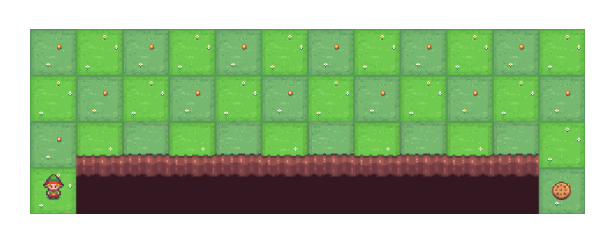

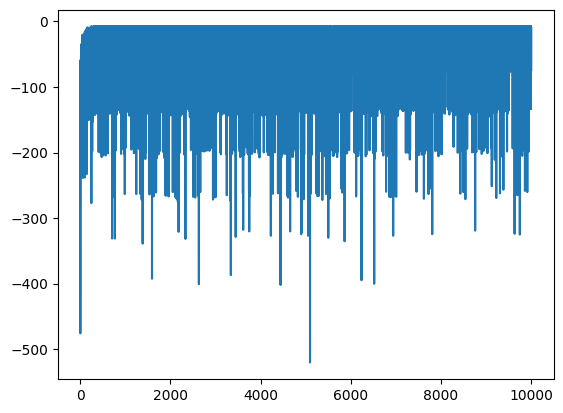

In [35]:
plt.close()
plt.figure()
plt.plot(all_penalties)
plt.show()

In [36]:
env.reset()

epochs = 0
penalties, reward = 0, 0

frames = [] # for animation

done = False

while not done:
    action = np.argmax(q_table[state])
    state, reward, done, truncated, info = env.step(action)

    if reward == -10:
        penalties += 1
    
    # Put each rendered frame into dict for animation
    frames.append({
        'frame': env.render(),
        'state': state,
        'action': action,
        'reward': reward
        }
    )

    epochs += 1

    if truncated:
      print("Truncated!")
      break 

    

print("Done: {}".format(done))
print("Timesteps taken: {}".format(epochs))
print("Penalties incurred: {}".format(penalties))

Done: True
Timesteps taken: 14
Penalties incurred: 0


In [37]:
html = display_animation(frames)
display.display(html)

### SARSA (State-Action-Reward-State-Action)

SARSA is an **on-policy**, value-based reinforcement learning algorithm. Its name is an acronym for the sequence of events that occur in its update rule: **S**tate, **A**ction, **R**eward, **S**tate, **A**ction ($S, A, R, S', A'$).

### The Update Rule

While Q-learning estimates the value of the *optimal* future action (using `max`), SARSA updates its Q-values based on the action actually taken by the current policy.

$$Q(S,A) \leftarrow (1- \alpha) Q(S,A) + \alpha \big( R + \gamma Q(S', A') \big)$$

#### Key Difference from Q-learning:

* **Q-learning (Off-policy):** Updates by looking at the maximum possible reward in the next state, regardless of which action it actually chooses next.
* **SARSA (On-policy):** Updates by looking at the reward of the specific action $A'$ it *actually* selects in state $S'$.

### The Algorithm

Breaking the process down into its logical steps:

1. **Initialize** the Q-table with all zeros.
2. **For each episode:**
* Initialize the starting state $S$.
* Choose an initial action $A$ from $S$ using a policy derived from the Q-table (e.g., $\epsilon$-greedy).
* **For each step of the episode:**
1. **Take** action $A$, then observe reward $R$ and the next state $S'$.
2. **Choose** the next action $A'$ from state $S'$ using the same policy.
3. **Update** the Q-table using the SARSA update rule.
4. **Transition:** Set $S \leftarrow S'$ and $A \leftarrow A'$.


### On-Policy vs. Off-Policy

The Q-value update rule is what fundamentally distinguishes SARSA from Q-learning.

* **Observation:** In SARSA, the "Temporal Difference" value is calculated using the current state-action pair and the *actual* next state-action pair.
* **Requirement:** This means we must know the next action our policy takes **before** we can perform the update step for the current state.

Because SARSA updates its estimates based specifically on the behavior of the current policy (including its mistakes or exploration), it is considered **on-policy**. This often makes SARSA more "conservative" or safer during the learning process compared to the aggressive nature of Q-learning.

##### **1. Repeat the previous computations with SARSA. How do they compare with the ones with Q Learning?**



In [42]:
from tqdm import tqdm
env = gym.make('CliffWalking-v1',render_mode = "rgb_array").env

q_table = np.zeros([env.observation_space.n, env.action_space.n])

# Hyperparameters
alpha = 0.1
gamma = 0.95
epsilon = 0.1
Iter = 10000
max_iter_per_episode = 100

# For plotting metrics
all_epochs = []
all_penalties = []

for episode in tqdm(range(Iter)):
    env.reset()

    total_reward = 0

    state = env.env.unwrapped.s 
    max_q_action = np.argmax(q_table[state,:])
    prob = np.random.rand()

    if prob > epsilon:
        action = max_q_action
    else:
        while True:
            action = np.random.randint(env.action_space.n)
            if action != max_q_action:
                break

    for it in range(max_iter_per_episode):
        state = env.env.unwrapped.s 

        state_prime, reward, done, truncated, info = env.step(action)

        prob = np.random.rand()

        max_q_action = np.argmax(q_table[state_prime,:])
        if prob > epsilon:
            action_prime = max_q_action
        else:
            while True:
                action_prime = np.random.randint(env.action_space.n)
                if action_prime != max_q_action:
                    break
        
        total_reward += gamma*reward

        q_table[state, action] = (1 - alpha)*q_table[state,action] + alpha*(reward + gamma*q_table[state_prime,action_prime]) 

        action = action_prime
        
        if done:
            break
    
    all_penalties.append(total_reward)

  0%|          | 0/10000 [00:00<?, ?it/s]

100%|██████████| 10000/10000 [00:03<00:00, 3092.85it/s]


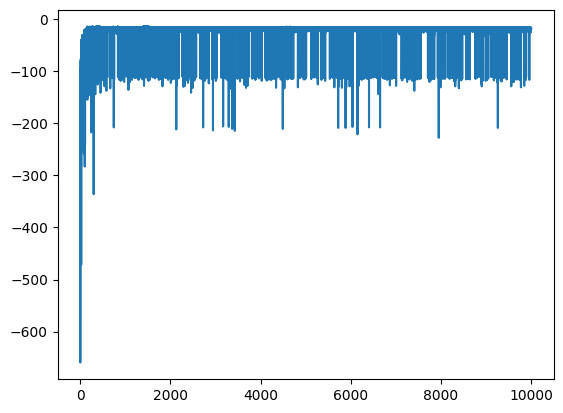

In [44]:
plt.figure()
plt.plot(all_penalties)
plt.show()

In [45]:

env.reset()

epochs = 0
penalties, reward = 0, 0

frames = [] # for animation

done = False

while not done:
    action = np.argmax(q_table[state])
    state, reward, done, truncated, info = env.step(action)

    if reward == -10:
        penalties += 1
    
    # Put each rendered frame into dict for animation
    frames.append({
        'frame': env.render(),
        'state': state,
        'action': action,
        'reward': reward
        }
    )

    epochs += 1

    if truncated:
      print("Truncated!")
      break 

    

print("Done: {}".format(done))
print("Timesteps taken: {}".format(epochs))
print("Penalties incurred: {}".format(penalties))

Done: True
Timesteps taken: 18
Penalties incurred: 0


In [46]:
html = display_animation(frames)
display.display(html)